# Househunters Data

In [2]:
# Load required packages
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import pandas as pd       # 'as' := we abbreviate the package for common use
pd.options.mode.chained_assignment = None
import numpy as np
import seaborn as sns
import random
import os
import math
import matplotlib.pyplot as plt
import datetime
import itertools

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm
import xgboost as xgb

from sklearn.linear_model import LogisticRegression #Logistic regression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn import metrics #ROC curve

In [44]:
import Scripts.modeling_functions as mf

In [4]:
# b) Load data
os.chdir("C:/Users/KeijzerK/Git Repositories/3490 FML - Participant case files/2. Househunter case (large case)/")

# change directory if necessary
inputdata = pd.read_excel("190322 - HouseTable_vDef_excel.xlsx")

,ID,Price,Province,HouseType,ConstructionYear,CapacityHouse_m3,LivingArea_m2,ResidentialNeighborhood,QuietRoad,Garden,...,Num_WWB,Num_AO,Num_WW,Num_AOW,Municipality_Distance_hospital_km,Municipality_Distance_childDaycare_km,Municipality_Distance_largeSupermarket_km,Municipality_Distance_trainstation_km,Avg_WOZ_m2,Garden_validation
0,2684219,178082,Zeeland,Semidetached,2017,400.0,120.0,0,0,1.0,...,20,90,60,600,11.7,2.3,1.2,10.0,1698.226212,1
1,2681978,241403,FryslÃ¢n,Detached,1930,280.0,71.0,0,0,0.0,...,10,10,20,90,21.1,0.8,1.6,3.5,1695.027593,0
2,2684837,277145,Overijssel,Detached,1993,272.0,90.0,0,0,0.0,...,20,80,80,190,8.8,1.1,1.3,6.5,1668.157895,0
3,2684859,112522,Zeeland,Semidetached,1920,238.0,102.0,0,0,0.0,...,0,40,20,200,17.1,0.9,2.0,47.0,1100.000000,0
4,2675023,93746,Drenthe,TownHouse,1969,250.0,56.0,0,0,0.0,...,20,80,70,290,4.4,1.2,1.0,4.2,1250.000000,0
5,2684766,111429,Overijssel,Semidetached,1920,270.0,70.0,0,0,1.0,...,20,100,110,550,16.8,1.2,1.5,7.4,1500.000000,1
6,2685260,127027,Limburg,TownHouse,1930,350.0,100.0,0,0,1.0,...,20,70,60,260,12.3,0.8,1.3,5.1,1600.000000,1
7,2683411,357502,Groningen,Detached,1897,441.0,143.0,0,0,1.0,...,40,100,60,240,13.7,0.8,1.2,3.8,1100.000000,1
8,2674813,145222,FryslÃ¢n,TownHouse,1972,414.0,116.0,0,0,1.0,...,80,110,70,390,18.6,3.5,1.2,15.8,1250.000000,1
9,2691206,192764,Zeeland,TownHouse,1964,265.0,80.0,1,1,1.0,...,70,140,70,470,6.4,0.8,1.1,33.3,2750.000000,1


## Data exploration

In [5]:
# a) Get an overview of the data
#    Get the number of rows and columns
print('(nrow, ncol):', inputdata.shape)     

#    Show a brief summary of the numeric variables
inputdata.describe()                        # min/max, count, mean, std and percentiles

(nrow, ncol): (3667, 30)


,ID,Price,ConstructionYear,CapacityHouse_m3,LivingArea_m2,ResidentialNeighborhood,QuietRoad,Garden,FirePlace,Balcony,...,Num_WWB,Num_AO,Num_WW,Num_AOW,Municipality_Distance_hospital_km,Municipality_Distance_childDaycare_km,Municipality_Distance_largeSupermarket_km,Municipality_Distance_trainstation_km,Avg_WOZ_m2,Garden_validation
count,3.667000e+03,3.667000e+03,3667.000000,3667.000000,3667.000000,3667.000000,3667.000000,2716.000000,3667.000000,3667.000000,...,3667.000000,3667.000000,3667.000000,3667.000000,3667.000000,3667.000000,3667.000000,3667.000000,3667.000000,3667.000000
mean,2.683852e+06,3.355942e+05,1968.374966,475.626872,132.150935,0.209163,0.186528,0.663476,0.035724,0.136079,...,238.581947,357.837469,210.452686,1327.043905,7.835042,0.824407,0.944151,6.586474,1803.535485,0.647668
std,1.058421e+04,1.633092e+05,35.014865,264.924015,58.871407,0.406766,0.389586,0.472608,0.185627,0.342919,...,288.817701,231.142913,132.369864,813.035900,6.200927,0.443916,0.369759,9.093516,529.434670,0.477762
min,2.250795e+06,-1.750700e+04,1816.000000,68.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.500000,0.400000,0.500000,1.000000,800.000000,0.000000
25%,2.681245e+06,2.212085e+05,1955.000000,322.000000,96.300000,0.000000,0.000000,0.000000,0.000000,0.000000,...,60.000000,180.000000,110.000000,670.000000,3.300000,0.500000,0.700000,2.400000,1500.000000,0.000000
50%,2.684540e+06,3.006830e+05,1975.000000,406.000000,120.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,150.000000,330.000000,200.000000,1260.000000,5.700000,0.700000,0.900000,3.000000,1700.000000,1.000000
75%,2.687806e+06,4.113925e+05,1994.500000,544.000000,150.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,300.000000,500.000000,290.000000,1870.000000,11.400000,1.000000,1.100000,7.300000,2000.000000,1.000000
max,2.693785e+06,1.594992e+06,2019.000000,1653.900000,384.030000,1.000000,1.000000,1.000000,1.000000,1.000000,...,2720.000000,1510.000000,900.000000,5160.000000,63.700000,6.300000,2.600000,50.700000,5350.000000,1.000000


In [6]:
# b) Check data type of each variable
print(pd.DataFrame(inputdata.dtypes, columns=['Datatype']))

                                          Datatype
ID                                           int64
Price                                        int64
Province                                    object
HouseType                                   object
ConstructionYear                             int64
CapacityHouse_m3                           float64
LivingArea_m2                              float64
ResidentialNeighborhood                      int64
QuietRoad                                    int64
Garden                                     float64
FirePlace                                    int64
Balcony                                      int64
Attic                                        int64
Back                                         int64
#Bedrooms                                    int64
StatusRank                                   int64
StatusScore                                float64
Urbanity_class                               int64
Avg_house_value_WOZ_1000euros  

In [7]:
# c) Get an overview of the NULLS in the dataset
nulls = pd.DataFrame(inputdata.isnull().sum(), columns=['# NULLS'])        # Number of NULLS 

lst={}                                                                     # Number of NULLS as a percentage
for col in inputdata.columns:                                       
    lst[col]=np.sum(inputdata.loc[:,col].isnull())/len(inputdata.loc[:,col])
percNulls = pd.DataFrame(pd.Series(lst), columns=['% NULLS'])

print(pd.concat([nulls, percNulls], axis=1))

                                           # NULLS  % NULLS
ID                                               0  0.00000
Price                                            0  0.00000
Province                                         0  0.00000
HouseType                                        0  0.00000
ConstructionYear                                 0  0.00000
CapacityHouse_m3                                 0  0.00000
LivingArea_m2                                    0  0.00000
ResidentialNeighborhood                          0  0.00000
QuietRoad                                        0  0.00000
Garden                                         951  0.25934
FirePlace                                        0  0.00000
Balcony                                          0  0.00000
Attic                                            0  0.00000
Back                                             0  0.00000
#Bedrooms                                        0  0.00000
StatusRank                              

Text(0, 0.5, '#')

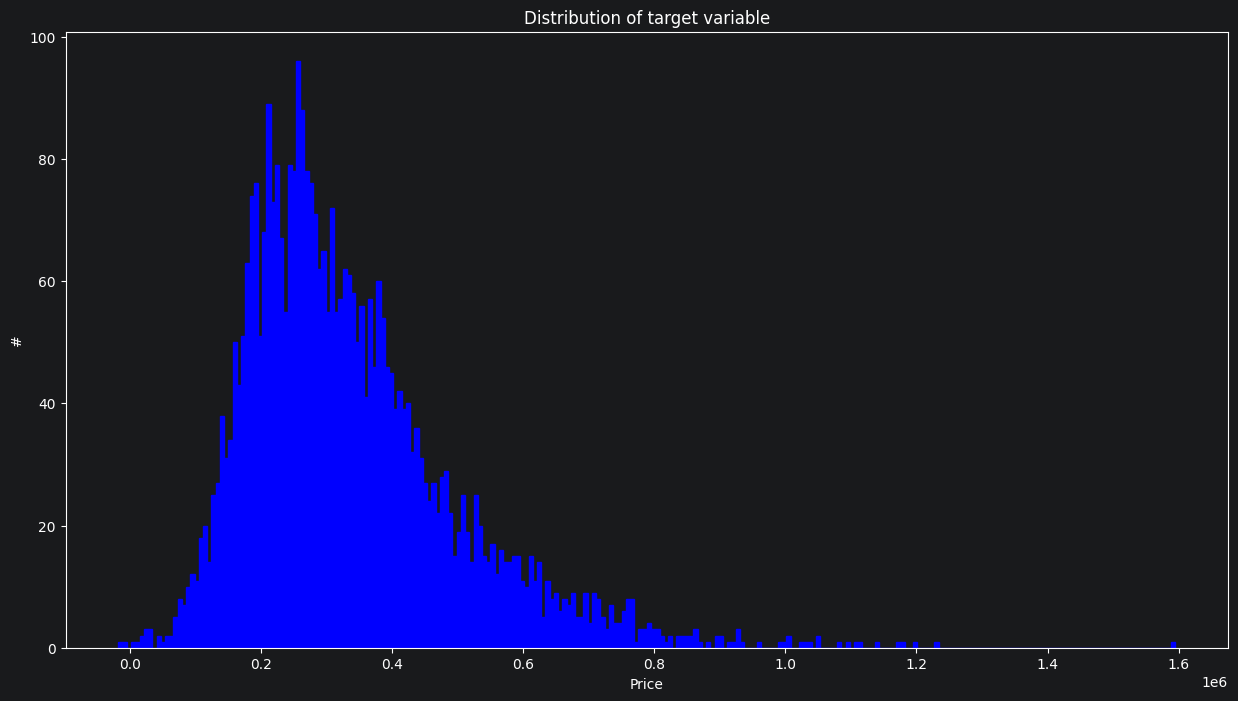

In [8]:
# d) Plot distribution of target variable
target = 'Price'

plt.figure(figsize=(15,8))
plt.hist((inputdata[target]), bins=250, color = 'blue', edgecolor = 'blue')
plt.title('Distribution of target variable')
plt.xlabel(target)
plt.ylabel('#')

#### Explore relations with target variable 'Price'

C:\Users\KeijzerK\AppData\Local\Temp\ipykernel_39448\3783143879.py:28: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(x, y, marker='o', cmap='blue')


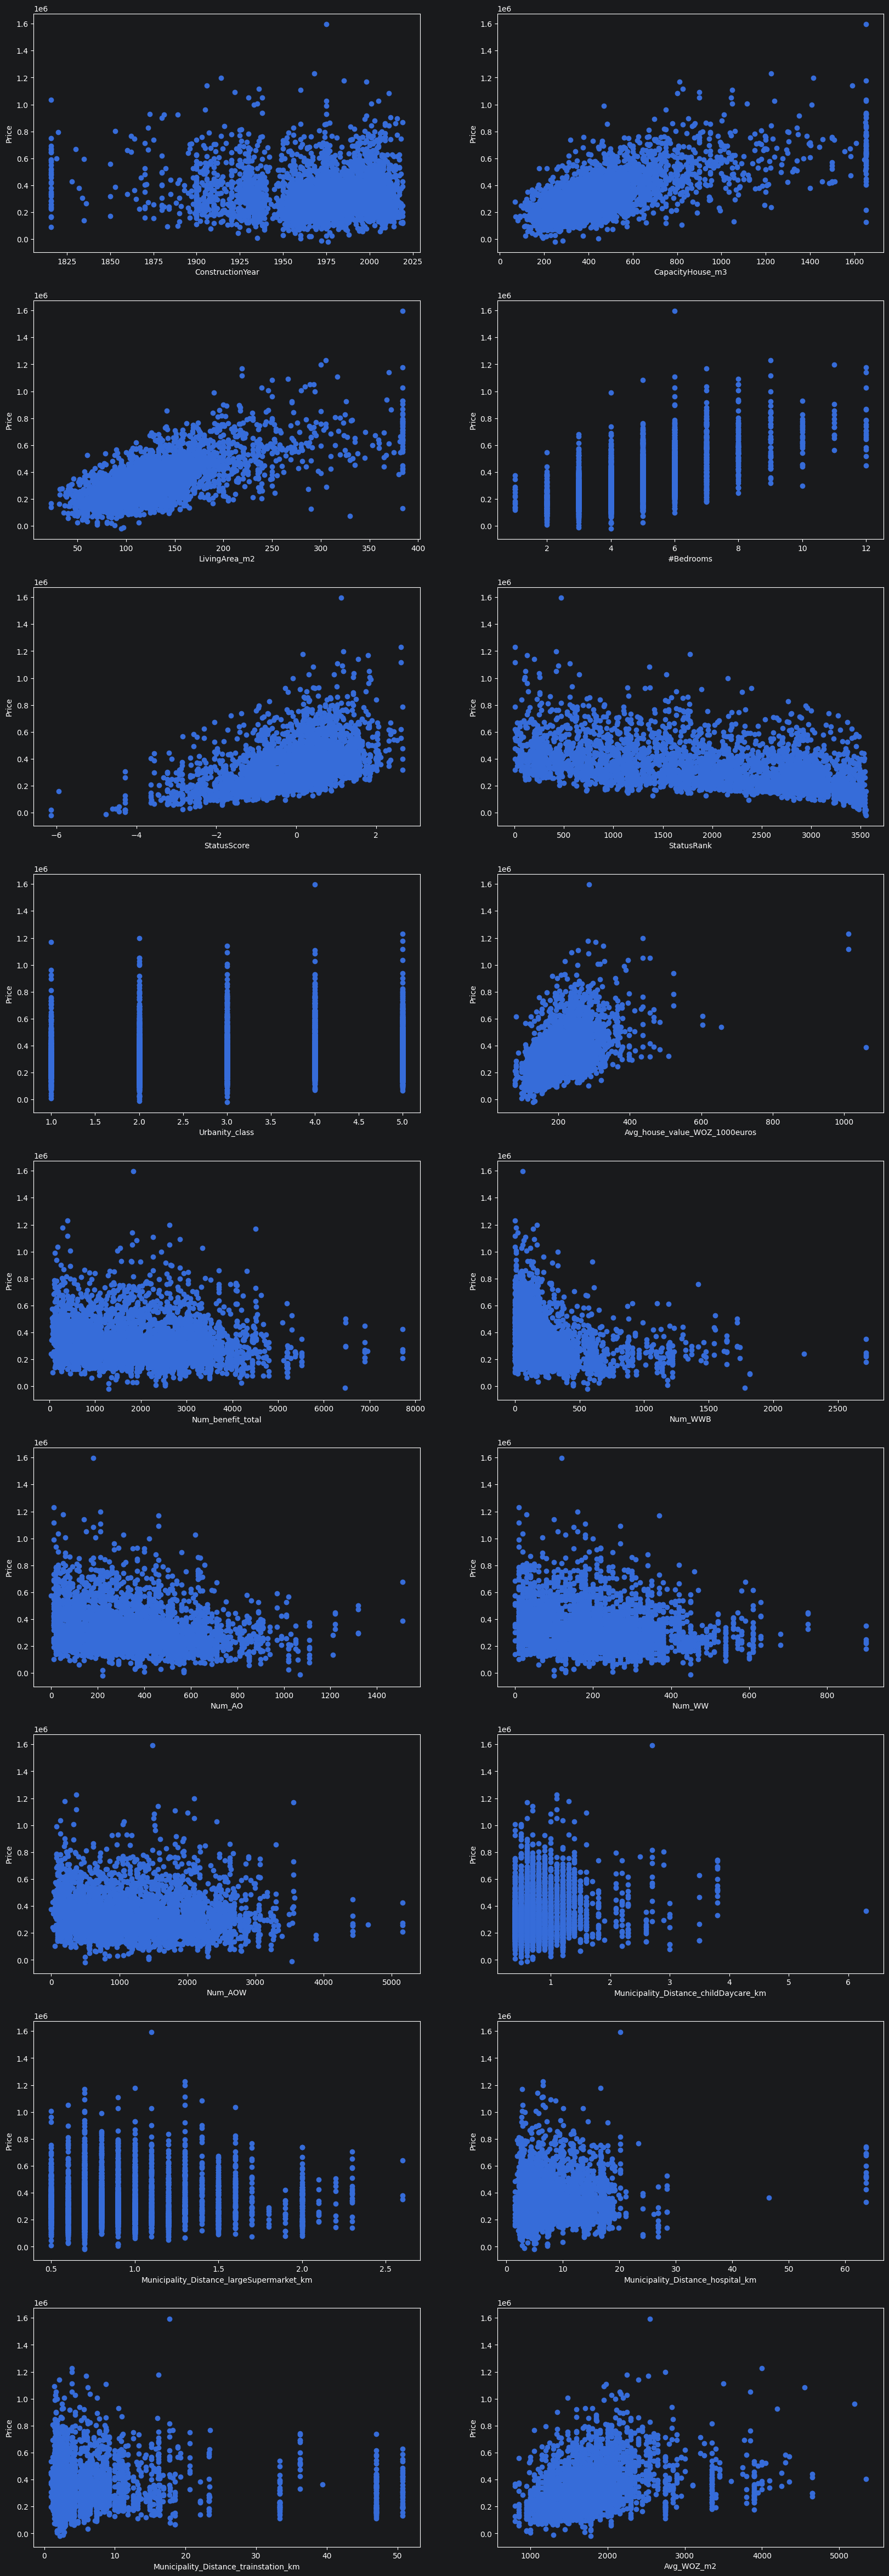

In [9]:
# e) Create scatter plot to see the relation between numerical (not dummy) variables and target variable
numericals = ['ConstructionYear'
              ,'CapacityHouse_m3'
              ,'LivingArea_m2'
              ,'#Bedrooms'
              ,'StatusScore'
              ,'StatusRank'
              ,'Urbanity_class'
              ,'Avg_house_value_WOZ_1000euros'
              ,'Num_benefit_total'
              ,'Num_WWB'
              ,'Num_AO'
              ,'Num_WW'
              ,'Num_AOW'
              ,'Municipality_Distance_childDaycare_km'
              ,'Municipality_Distance_largeSupermarket_km'
              ,'Municipality_Distance_hospital_km'
              ,'Municipality_Distance_trainstation_km'
              ,'Avg_WOZ_m2'
             ]  


plt.figure(figsize=(20,60))
for i, column in enumerate(numericals):
    plt.subplot(math.ceil(len(numericals)/2), 2, i+1)
    x = inputdata[column]
    y = inputdata[target]
    plt.scatter(x, y, marker='o', cmap='blue')
    plt.xlabel(column)
    plt.ylabel('Price')

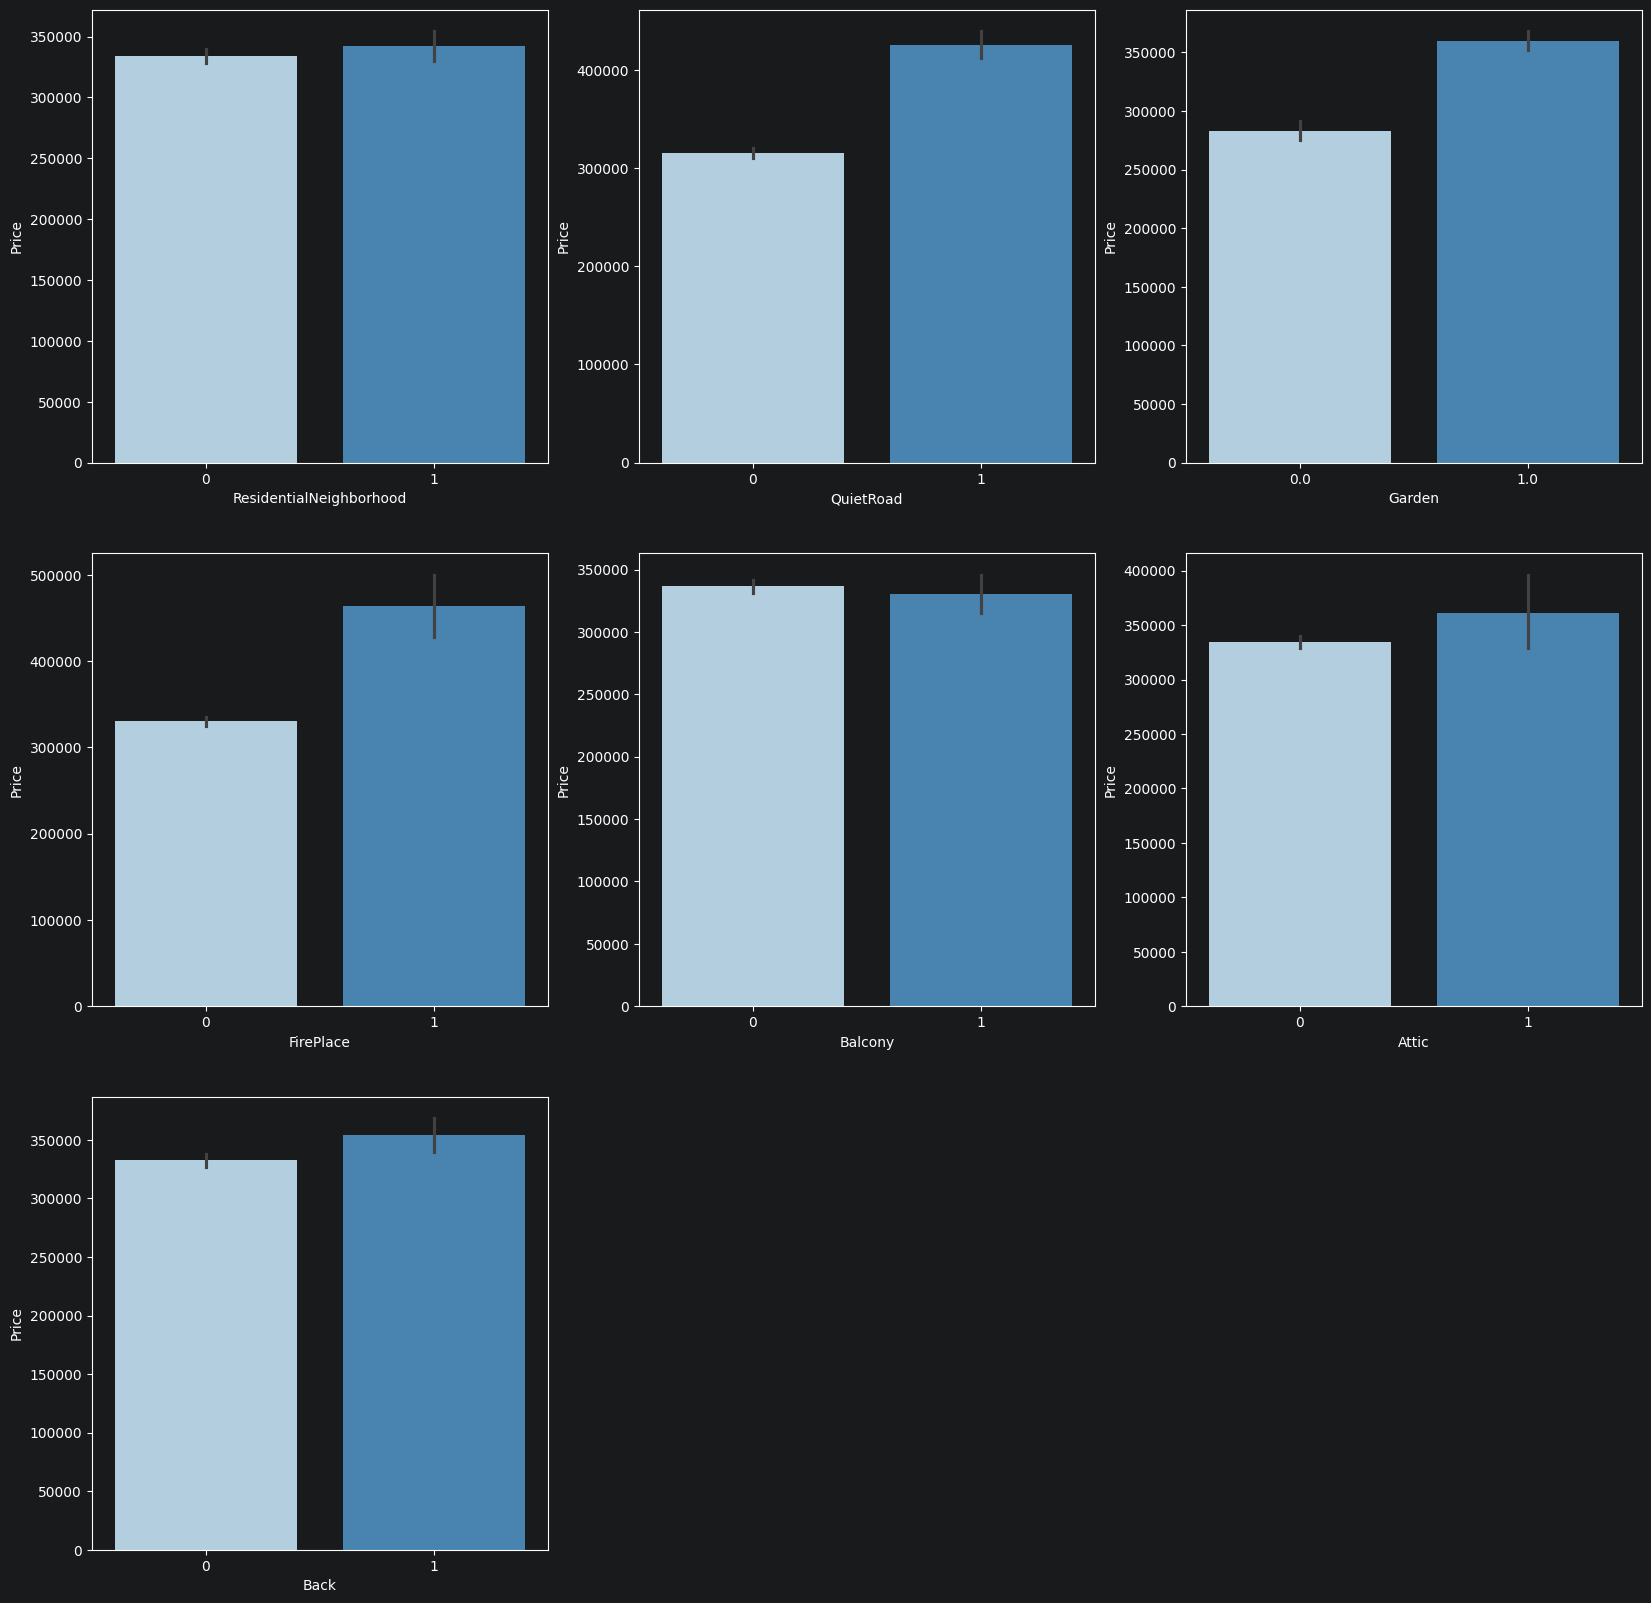

In [10]:
# f) Create barplot to see the relation between the dummy-variables and target variable
dummies = ['ResidentialNeighborhood'
           ,'QuietRoad'
           ,'Garden'
           ,'FirePlace'
           ,'Balcony'
           ,'Attic'
           ,'Back'
          ]


plt.figure(figsize=(20,20))
for i, column in enumerate(dummies):
    plt.subplot(math.ceil(len(dummies)/3), 3, i+1)
    sns.barplot(data=inputdata, x=column, y=target, palette='Blues')

<Figure size 1500x700 with 0 Axes>

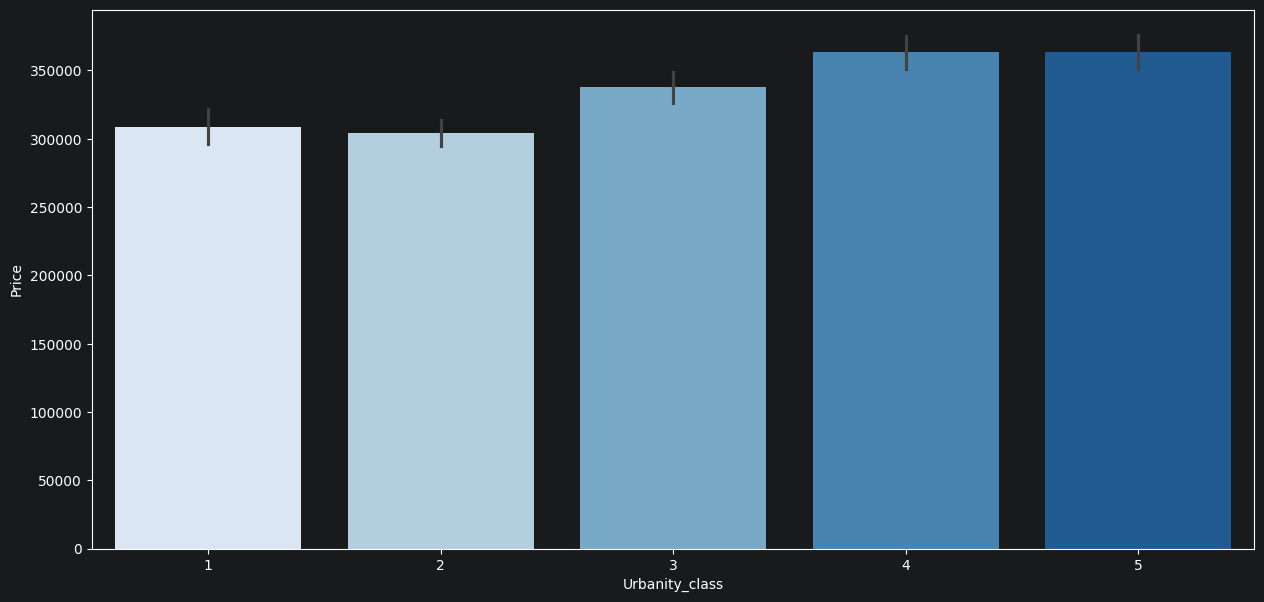

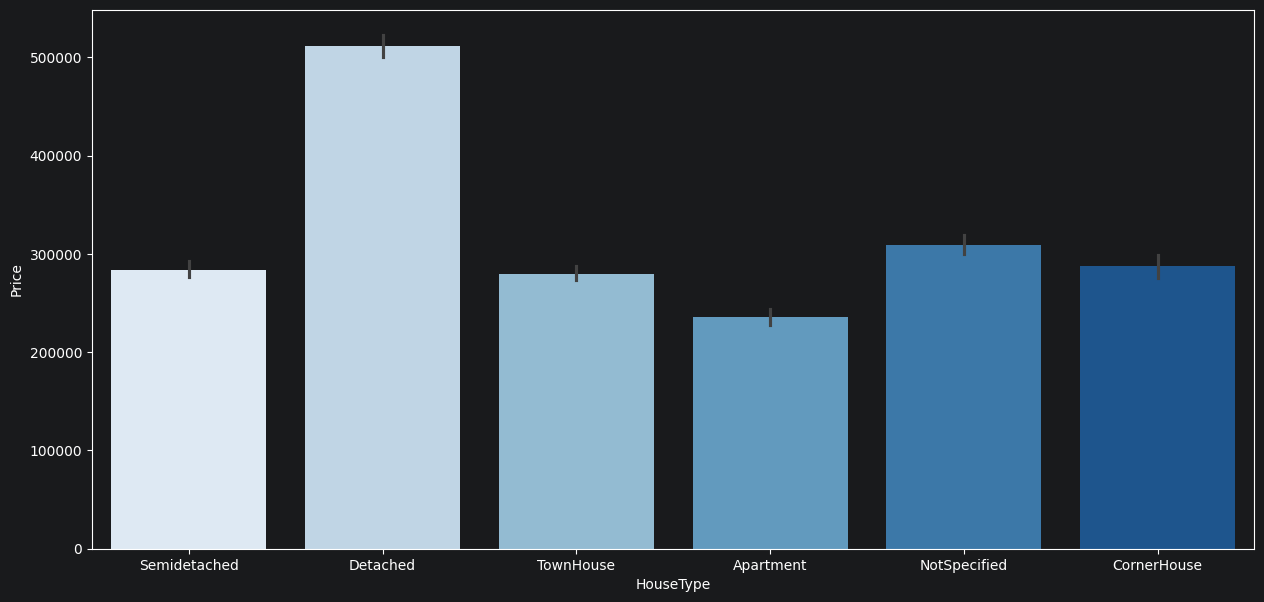

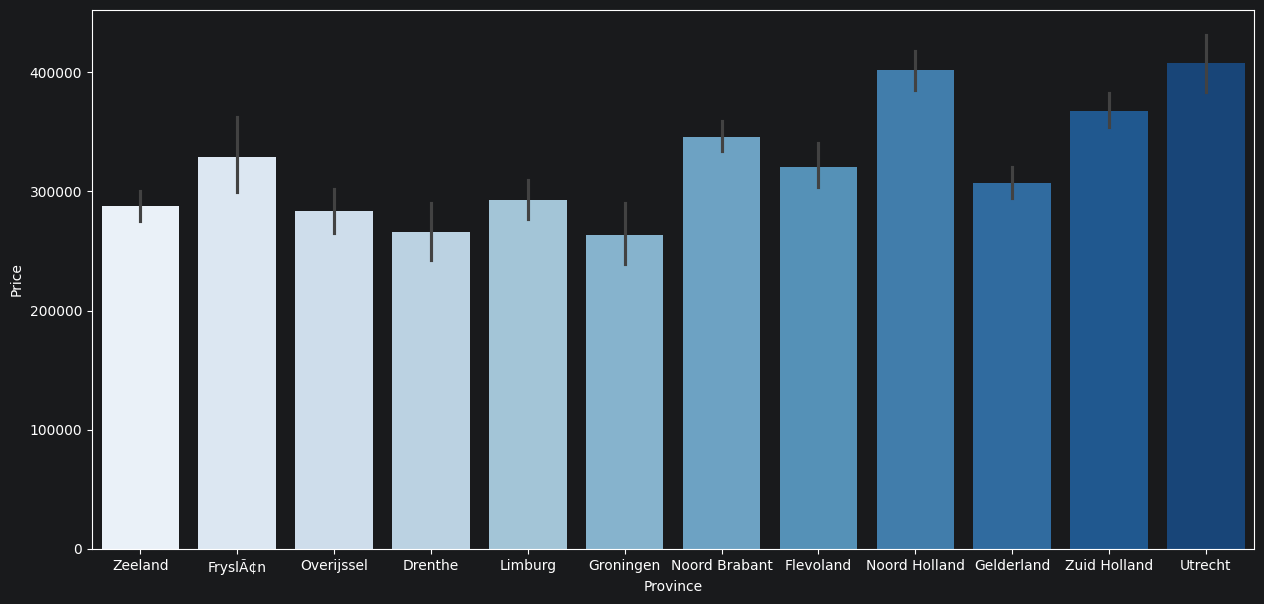

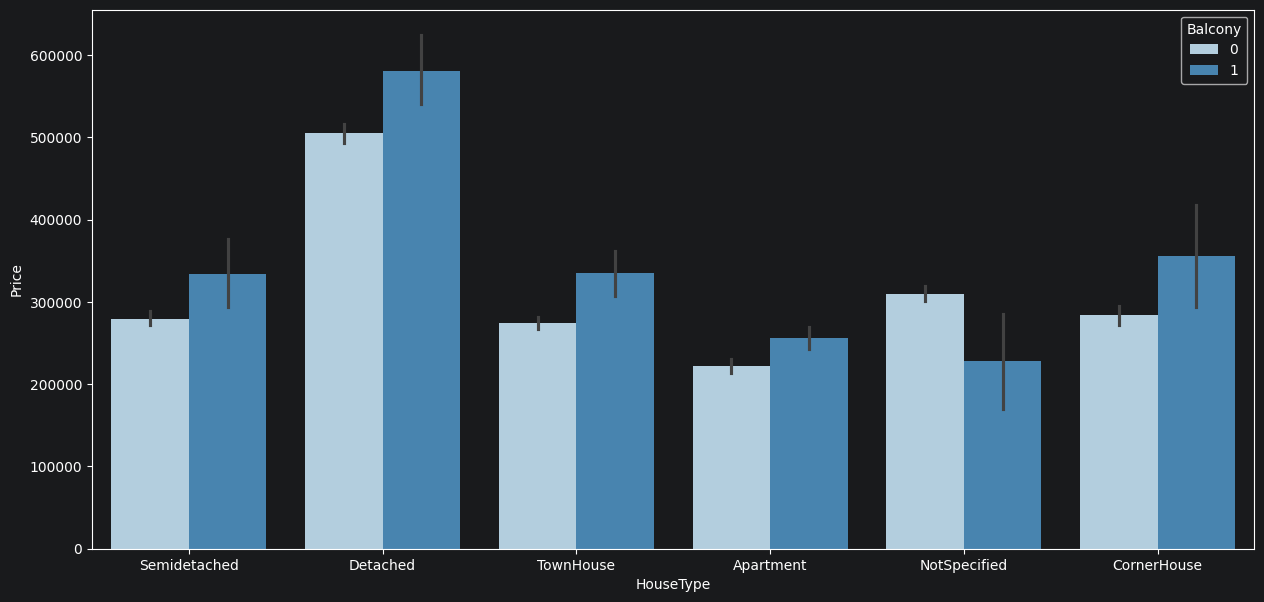

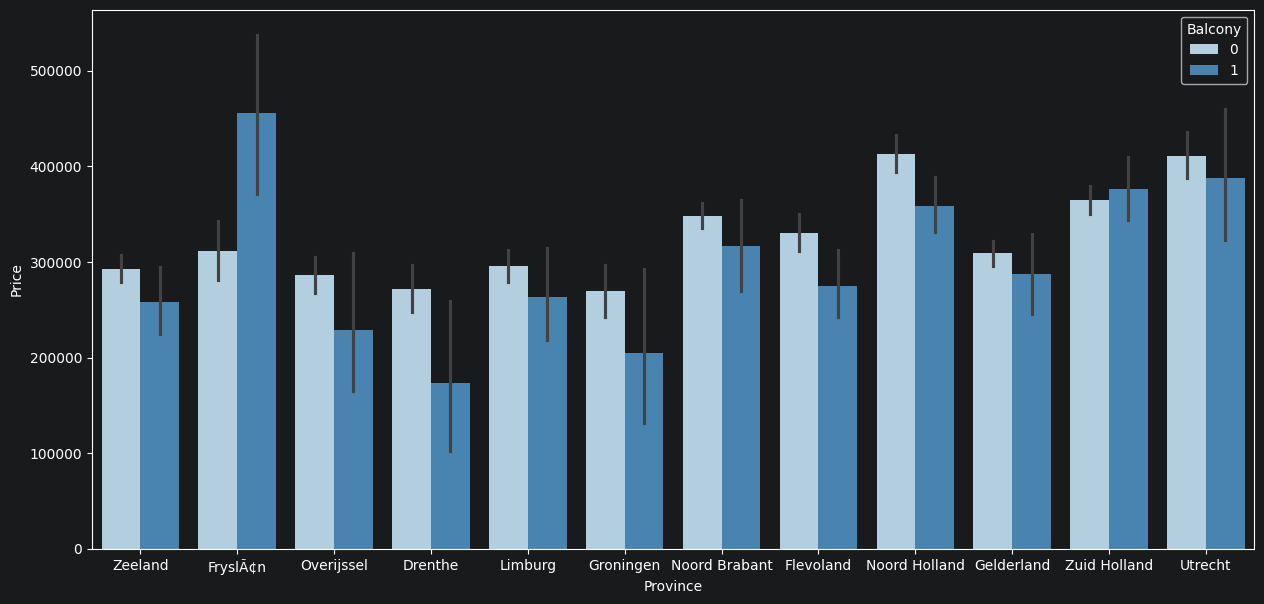

<Figure size 1500x700 with 0 Axes>

In [11]:
# g) Create barplot to see the relation between the categorical variables and the target variable
plt.figure(figsize=(15,7))
sns.barplot(data=inputdata, x='Urbanity_class', y=target, palette='Blues')
plt.figure(figsize=(15,7))
sns.barplot(data=inputdata, x='HouseType', y=target, palette='Blues')
plt.figure(figsize=(15,7))
sns.barplot(data=inputdata, x='Province', y=target, palette='Blues')

# Here you can include additional variables to explore
plt.figure(figsize=(15,7))
sns.barplot(data=inputdata, x='HouseType', y=target, hue='Balcony', palette='Blues')
plt.figure(figsize=(15,7))
sns.barplot(data=inputdata, x='Province', y=target, hue='Balcony', palette='Blues')
plt.figure(figsize=(15,7))

In [13]:
# h) Print correlation with the target variable
corrmat = inputdata.select_dtypes(include='number').corr().round(2)
print(corrmat["Price"].sort_values(ascending=False))

Price                                        1.00
LivingArea_m2                                0.69
CapacityHouse_m3                             0.67
#Bedrooms                                    0.62
Avg_house_value_WOZ_1000euros                0.51
StatusScore                                  0.49
Avg_WOZ_m2                                   0.32
QuietRoad                                    0.26
Garden_validation                            0.24
Garden                                       0.23
Urbanity_class                               0.15
FirePlace                                    0.15
Municipality_Distance_childDaycare_km        0.11
Municipality_Distance_hospital_km            0.09
Municipality_Distance_largeSupermarket_km    0.04
Back                                         0.04
Attic                                        0.03
Municipality_Distance_trainstation_km        0.03
ResidentialNeighborhood                      0.02
ID                                          -0.01


<Axes: >

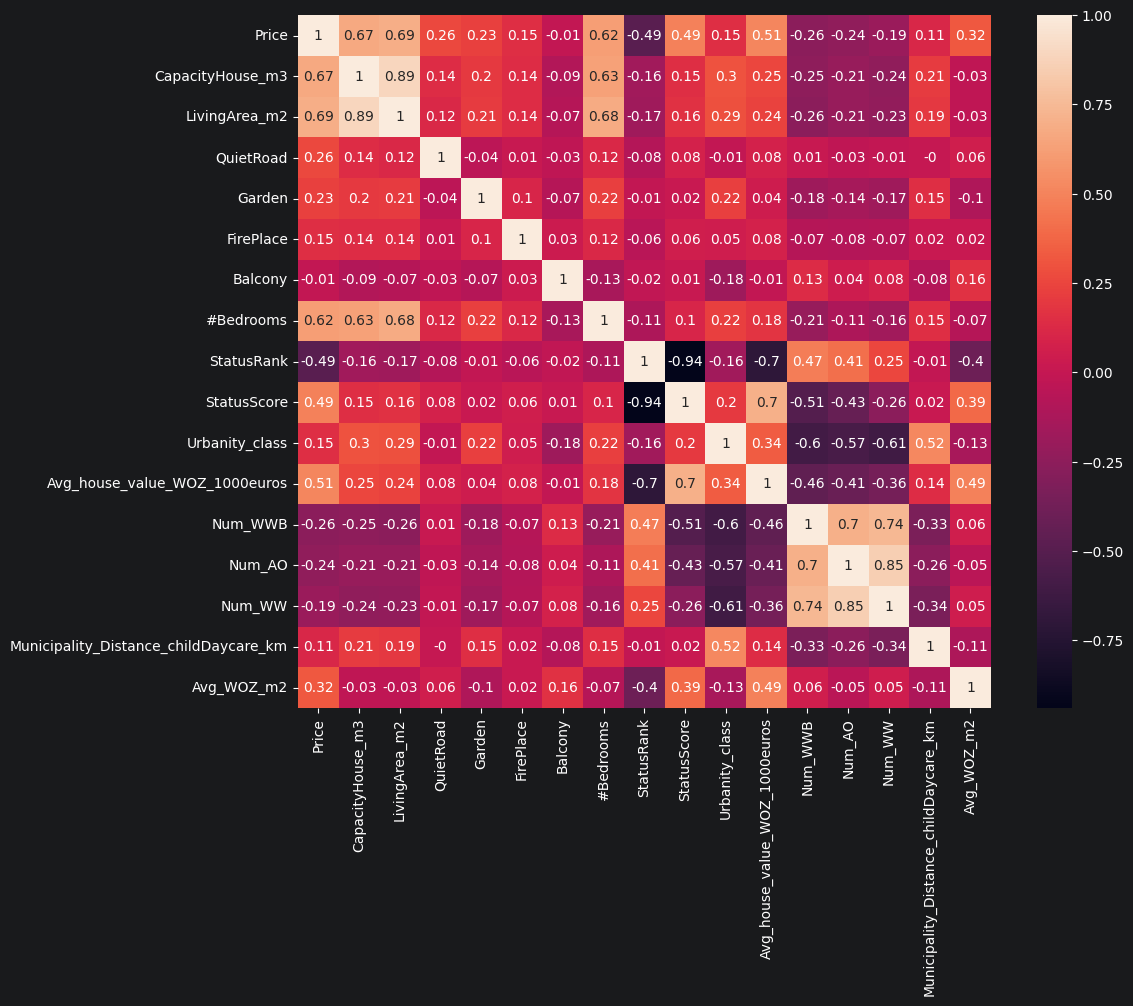

In [14]:
#    Show correlation matrix to look for mutual correlations
columns = ['Price'
          # ,'ConstructionYear'
           ,'CapacityHouse_m3'
           ,'LivingArea_m2'
          # ,'ResidentialNeighborhood'
           ,'QuietRoad'
           ,'Garden'
           ,'FirePlace'
           ,'Balcony'
          # ,'Attic'
          # ,'Back'
           ,'#Bedrooms'
           ,'StatusRank'
           ,'StatusScore'
           ,'Urbanity_class'
           ,'Avg_house_value_WOZ_1000euros'
          # ,'Num_benefit_total'
           ,'Num_WWB'
           ,'Num_AO'
           ,'Num_WW'
          # ,'Num_AOW'
          # ,'Municipality_Distance_hospital_km'
           ,'Municipality_Distance_childDaycare_km'
          # ,'Municipality_Distance_largeSupermarket_km'
          # ,'Municipality_Distance_trainstation_km'
           ,'Avg_WOZ_m2'
          ]

correlation = inputdata[columns]
corrmat = correlation.corr().round(2)
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat, square=True, annot=True)

## Data preparation

In [15]:
print(inputdata.shape)

(3667, 30)


In [16]:
# a) Drop rows with a price <= 2000, as these are probably for rent, and price >= 1.500.000, as these are outliers
inputdata = inputdata[~(inputdata['Price']<=3000)]
inputdata = inputdata[~(inputdata['Price']>=1500000)]

In [17]:
# b) Feature engineering
#    i. Add column Price per meter2
inputdata['Price_m2'] = inputdata['Price']/inputdata['LivingArea_m2']

#    ii. Categorize the houses according to the construction year
inputdata['Age_cat'] = inputdata['ConstructionYear']
inputdata['Age_cat'][inputdata['ConstructionYear']<1940] = 'Before war'
inputdata['Age_cat'][(inputdata['ConstructionYear']>=1940) & (inputdata['ConstructionYear']<1990)] = 'Existing'
inputdata['Age_cat'][inputdata['ConstructionYear']>=1990] = 'New construction'

In [18]:
#    iii. Create dummy-variable whether a house in the city- or countryside
cityside = ['Noord Holland'
            ,'Zuid Holland'
            ,'Utrecht'
           ]

countryside = ['Zeeland'
              ,'Fryslân'
              ,'Groningen'
              ,'Drenthe'
              ]

inputdata['CitySide'] = inputdata['Province'].isin(cityside).astype(np.int8)
inputdata['CountrySide'] = inputdata['Province'].isin(countryside).astype(np.int8)

In [20]:
# Check missing values

nulls = pd.DataFrame(inputdata.isnull().sum(), columns=['# NULLS'])        # Number of NULLS 

lst={}                                                                     # Number of NULLS as a percentage
for col in inputdata.columns:                                       
    lst[col]=np.sum(inputdata.loc[:,col].isnull())/len(inputdata.loc[:,col])
percNulls = pd.DataFrame(pd.Series(lst), columns=['% NULLS'])

print(pd.concat([nulls, percNulls], axis=1))

                                           # NULLS   % NULLS
ID                                               0  0.000000
Price                                            0  0.000000
Province                                         0  0.000000
HouseType                                        0  0.000000
ConstructionYear                                 0  0.000000
CapacityHouse_m3                                 0  0.000000
LivingArea_m2                                    0  0.000000
ResidentialNeighborhood                          0  0.000000
QuietRoad                                        0  0.000000
Garden                                         949  0.259007
FirePlace                                        0  0.000000
Balcony                                          0  0.000000
Attic                                            0  0.000000
Back                                             0  0.000000
#Bedrooms                                        0  0.000000
StatusRank              

In [21]:
# Report columns with missing values
print(inputdata.isnull().sum()[inputdata.isnull().sum() > 0])

Garden    949
dtype: int64


In [22]:
# drop columns with missing values
inputdata = inputdata.dropna(axis=1)

In [23]:
# Dummmify the categorical variables
# Save the categorical variable columns

dataProv = inputdata['Province']
dataHouse = inputdata['HouseType']
dataAge = inputdata['Age_cat']
dataUrban = inputdata['Urbanity_class']
# dataGarden = inputdata['Garden']

#    Get/add dummies
categoricals = ['Province'
                ,'HouseType'
                ,'Age_cat'
                ,'Urbanity_class'
                # ,'Garden'
               ]
inputdata = pd.get_dummies(inputdata, columns=categoricals)

#    Add the original categorical column
inputdata['Province'] = dataProv
inputdata['HouseType'] = dataHouse
inputdata['Age_cat'] = dataAge
inputdata['Urbanity_class'] = dataUrban
# inputdata['Garden'] = dataGarden

In [31]:
bool_cols = inputdata.select_dtypes(include='bool').columns.tolist()
inputdata[bool_cols] = inputdata[bool_cols].astype(int)

# Modelling

In [32]:
# split the data into a train and test set
trainset, testset = train_test_split(inputdata, test_size=0.3, random_state=13)

In [ ]:
trainset.columns.values

In [106]:
# Design X and y
# ADD INDEPENDENT VARIABLES TO X YOU THINK HAVE (HIGH) IMPACT ON PRICE

X_variables = [#'Price_m2_HouseType'
               'LivingArea_m2'
               # ,'FirePlace'
               # 'Province_Groningen'
               # 'Province_Noord Holland'
               ,'StatusScore'
               ,'QuietRoad'
               # ,'Age_cat_Existing'
               # ,'Garden'
               ,'HouseType_Detached'
               # ,'Urbanity_class_1'
               #,'Urbanity_class_5'
                 ,'#Bedrooms' 
              ]

X_train = trainset.loc[:, X_variables]
X_test = testset.loc[:, X_variables]

y_train = trainset[target]
y_test = testset[target]

In [ ]:
print(X_train.dtypes)
print(X_train.select_dtypes(exclude='number').columns.tolist())

In [129]:
import importlib
import Scripts.modeling_functions as mf
import Scripts.plotting_functions as pf
import Scripts.formatting_functions as ff

In [107]:
# Define working directory
os.chdir("C:\\Users\\KeijzerK\\Git Repositories\\3490 FML - Participant case files\\2. Househunter case (large case)\\")

In [150]:
importlib.reload(mf)
importlib.reload(pf)
importlib.reload(ff)

<module 'Scripts.formatting_functions' from 'C:\\Users\\KeijzerK\\Git Repositories\\3490 FML - Participant case files\\2. Househunter case (large case)\\Scripts\\formatting_functions.py'>

### Linear regression

In [ ]:
linear_model = mf.perform_linear_regression(X_train, y_train, X_test, y_test)

fig = pf.plot_predicted_vs_actual(y_test, linear_model['test_predictions'])

### Logistic regression

In [86]:
# Compute threshold on training data only (avoid data leakage)
# threshold = y_train.quantile(0.75)
threshold = np.median(y_train)

# Create binary target: 1 if Price > 75th percentile, 0 otherwise
y_train_binary = (y_train >= threshold).astype(int)
y_test_binary = (y_test >= threshold).astype(int)

In [151]:
logistic_model = mf.perform_logistic_regression(X_train, y_train_binary, X_test, y_test_binary)

cm = logistic_model["test_metrics"]["confusion_matrix"]
classes = ["Low Price (0)", "High Price (1)"]

conf_matrix_plot = pf.plot_confusion_matrix(cm, classes, title="Logistic Regression - Confusion Matrix")

# ROC curve
y_test_prob = logistic_model["test_probs"]
roc_curve = pf.plot_roc_curve(y_test_binary, y_test_prob, True, title="Logistic Regression - ROC Curve")

Optimization terminated successfully.
         Current function value: 0.207797
         Iterations 8


### Decision Tree

In [147]:
tree_model = mf.perform_decision_tree(X_train, y_train_binary, X_test, y_test_binary, max_depth=3)

tree_plot = pf.plot_decision_tree(
    model        = tree_model["model"],
    feature_names= X_train.columns.tolist(),
    class_names  = classes,
    title        = "Decision Tree Classifier"
)

### Saving results

In [148]:
all_models = {
        "Linear":   linear_model,
        "Logistic": logistic_model,
        "Decision Tree": tree_model
    }

ff.export_metrics_to_excel(all_models, filename="all_model_results")

Saved to all_model_results.xlsx


'all_model_results.xlsx'